# 03 — Airport Taxi Demand and Flight Arrival Analysis

This notebook combines the processed Yellow Taxi airport pickup-demand panel with the BTS scheduled flight-arrival panel for JFK and LaGuardia Airport from January to June 2025.

The analysis investigates whether scheduled flight arrivals are associated with subsequent taxi pickup demand and whether this relationship differs across airports and time lags. The objective is to identify patterns that can support practical taxi-driver positioning recommendations.

In [1]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql import Window

import pandas as pd
import numpy as np

spark = (
    SparkSession.builder
    .appName("MAST30034_Project1_Analysis")
    .getOrCreate()
)

print("Spark version:", spark.version)

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/08/31 19:02:49 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/08/31 19:02:50 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.


Spark version: 4.2.0


## 1. Load Processed Airport-Hour Data

Both processed datasets contain one record per airport-hour for JFK and LaGuardia over the same January–June 2025 study period.

The taxi dataset records Yellow Taxi pickups, while the flight dataset records the number of scheduled flight arrivals.

In [2]:
TAXI_PATH = "../data/processed/hourly_airport_taxi_demand.parquet"
FLIGHT_PATH = "../data/processed/hourly_flight_arrivals.parquet"

taxi = spark.read.parquet(TAXI_PATH)
flights = spark.read.parquet(FLIGHT_PATH)

print("Taxi rows:", taxi.count())
print("Flight rows:", flights.count())

print("Taxi columns:", taxi.columns)
print("Flight columns:", flights.columns)

Taxi rows: 8688
Flight rows: 8688
Taxi columns: ['airport', 'pickup_hour', 'taxi_pickups']
Flight columns: ['airport', 'arrival_hour', 'scheduled_arrivals']


In [3]:
taxi_analysis = taxi.select(
    "airport",
    F.col("pickup_hour").alias("hour"),
    "taxi_pickups"
)

flight_analysis = flights.select(
    "airport",
    F.col("arrival_hour").alias("hour"),
    "scheduled_arrivals"
)

In [4]:
taxi_analysis.printSchema()
flight_analysis.printSchema()

root
 |-- airport: string (nullable = true)
 |-- hour: timestamp_ntz (nullable = true)
 |-- taxi_pickups: long (nullable = true)

root
 |-- airport: string (nullable = true)
 |-- hour: timestamp_ntz (nullable = true)
 |-- scheduled_arrivals: long (nullable = true)



In [5]:
airport_hour_panel = (
    taxi_analysis
    .join(
        flight_analysis,
        on=["airport", "hour"],
        how="inner"
    )
    .orderBy("airport", "hour")
)

print("Merged rows:", airport_hour_panel.count())

airport_hour_panel.groupBy("airport").count().orderBy("airport").show()

Merged rows: 8688
+-------+-----+
|airport|count|
+-------+-----+
|    JFK| 4344|
|    LGA| 4344|
+-------+-----+



In [6]:
airport_hour_panel = (
    airport_hour_panel
    .withColumn("date", F.to_date("hour"))
    .withColumn("hour_of_day", F.hour("hour"))
    .withColumn("day_of_week", F.dayofweek("hour"))
    .withColumn("month", F.month("hour"))
)

airport_hour_panel.select(
    "airport",
    "hour",
    "hour_of_day",
    "day_of_week",
    "month",
    "scheduled_arrivals",
    "taxi_pickups"
).show(10, truncate=False)

+-------+-------------------+-----------+-----------+-----+------------------+------------+
|airport|hour               |hour_of_day|day_of_week|month|scheduled_arrivals|taxi_pickups|
+-------+-------------------+-----------+-----------+-----+------------------+------------+
|JFK    |2025-01-01 00:00:00|0          |4          |1    |4                 |233         |
|JFK    |2025-01-01 01:00:00|1          |4          |1    |0                 |74          |
|JFK    |2025-01-01 02:00:00|2          |4          |1    |0                 |72          |
|JFK    |2025-01-01 03:00:00|3          |4          |1    |0                 |20          |
|JFK    |2025-01-01 04:00:00|4          |4          |1    |1                 |23          |
|JFK    |2025-01-01 05:00:00|5          |4          |1    |5                 |87          |
|JFK    |2025-01-01 06:00:00|6          |4          |1    |10                |168         |
|JFK    |2025-01-01 07:00:00|7          |4          |1    |13                |12

## 2. Exploratory Data Analysis

We first examine the temporal patterns of scheduled flight arrivals and Yellow Taxi pickup demand at JFK and LaGuardia. The analysis focuses on whether the two series exhibit similar hourly patterns and whether taxi demand tends to peak at the same time as, or after, scheduled flight arrivals.

These descriptive patterns provide the motivation for the subsequent lagged relationship analysis.

In [7]:
# Summarise taxi demand and scheduled arrivals by airport
airport_summary = (
    airport_hour_panel
    .groupBy("airport")
    .agg(
        F.round(F.mean("scheduled_arrivals"), 2).alias("mean_scheduled_arrivals"),
        F.expr(
            "percentile_approx(scheduled_arrivals, 0.5)"
        ).alias("median_scheduled_arrivals"),
        F.max("scheduled_arrivals").alias("max_scheduled_arrivals"),
        F.round(F.mean("taxi_pickups"), 2).alias("mean_taxi_pickups"),
        F.expr(
            "percentile_approx(taxi_pickups, 0.5)"
        ).alias("median_taxi_pickups"),
        F.max("taxi_pickups").alias("max_taxi_pickups")
    )
    .orderBy("airport")
)

airport_summary.show(truncate=False)

+-------+-----------------------+-------------------------+----------------------+-----------------+-------------------+----------------+
|airport|mean_scheduled_arrivals|median_scheduled_arrivals|max_scheduled_arrivals|mean_taxi_pickups|median_taxi_pickups|max_taxi_pickups|
+-------+-----------------------+-------------------------+----------------------+-----------------+-------------------+----------------+
|JFK    |11.83                  |13                       |28                    |224.62           |203                |741             |
|LGA    |15.22                  |19                       |31                    |146.12           |155                |578             |
+-------+-----------------------+-------------------------+----------------------+-----------------+-------------------+----------------+



In [8]:
# Calculate mean scheduled arrivals and taxi pickups by airport and hour of day
hourly_profile = (
    airport_hour_panel
    .groupBy("airport", "hour_of_day")
    .agg(
        F.mean("scheduled_arrivals").alias("mean_scheduled_arrivals"),
        F.mean("taxi_pickups").alias("mean_taxi_pickups")
    )
    .orderBy("airport", "hour_of_day")
)

print("Aggregated rows:", hourly_profile.count())

hourly_profile.show(48, truncate=False)

Aggregated rows: 48
+-------+-----------+-----------------------+------------------+
|airport|hour_of_day|mean_scheduled_arrivals|mean_taxi_pickups |
+-------+-----------+-----------------------+------------------+
|JFK    |0          |7.425414364640884      |233.88950276243094|
|JFK    |1          |1.292817679558011      |126.43093922651934|
|JFK    |2          |0.011049723756906077   |43.73480662983425 |
|JFK    |3          |0.0                    |23.314917127071823|
|JFK    |4          |0.850828729281768      |21.790055248618785|
|JFK    |5          |8.30939226519337       |80.86187845303867 |
|JFK    |6          |7.834254143646409      |150.09944751381215|
|JFK    |7          |21.19889502762431      |167.66298342541435|
|JFK    |8          |12.397790055248619     |124.82872928176796|
|JFK    |9          |9.508287292817679      |122.23204419889503|
|JFK    |10         |13.447513812154696     |142.97790055248618|
|JFK    |11         |10.204419889502763     |151.34806629834253|
|JFK 

In [9]:
hourly_profile_pd = hourly_profile.toPandas()

hourly_profile_pd.head()

,airport,hour_of_day,mean_scheduled_arrivals,mean_taxi_pickups
0,JFK,0,7.425414,233.889503
1,JFK,1,1.292818,126.430939
2,JFK,2,0.011050,43.734807
3,JFK,3,0.000000,23.314917
4,JFK,4,0.850829,21.790055


In [10]:
# Standardise each series within airport to compare temporal patterns
hourly_profile_pd["flight_index"] = (
    hourly_profile_pd
    .groupby("airport")["mean_scheduled_arrivals"]
    .transform(lambda x: (x - x.mean()) / x.std())
)

hourly_profile_pd["taxi_index"] = (
    hourly_profile_pd
    .groupby("airport")["mean_taxi_pickups"]
    .transform(lambda x: (x - x.mean()) / x.std())
)

In [11]:
import matplotlib.pyplot as plt

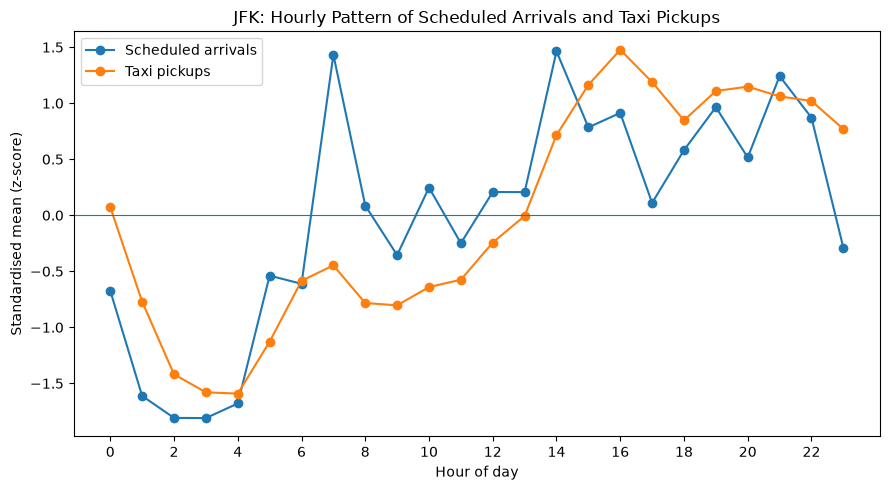

In [12]:
# Plot standardised hourly patterns for JFK
jfk_profile = hourly_profile_pd[
    hourly_profile_pd["airport"] == "JFK"
]

plt.figure(figsize=(9, 5))

plt.plot(
    jfk_profile["hour_of_day"],
    jfk_profile["flight_index"],
    marker="o",
    label="Scheduled arrivals"
)

plt.plot(
    jfk_profile["hour_of_day"],
    jfk_profile["taxi_index"],
    marker="o",
    label="Taxi pickups"
)

plt.axhline(0, linewidth=0.8)

plt.xlabel("Hour of day")
plt.ylabel("Standardised mean (z-score)")
plt.title("JFK: Hourly Pattern of Scheduled Arrivals and Taxi Pickups")
plt.xticks(range(0, 24, 2))
plt.legend()
plt.tight_layout()

plt.show()

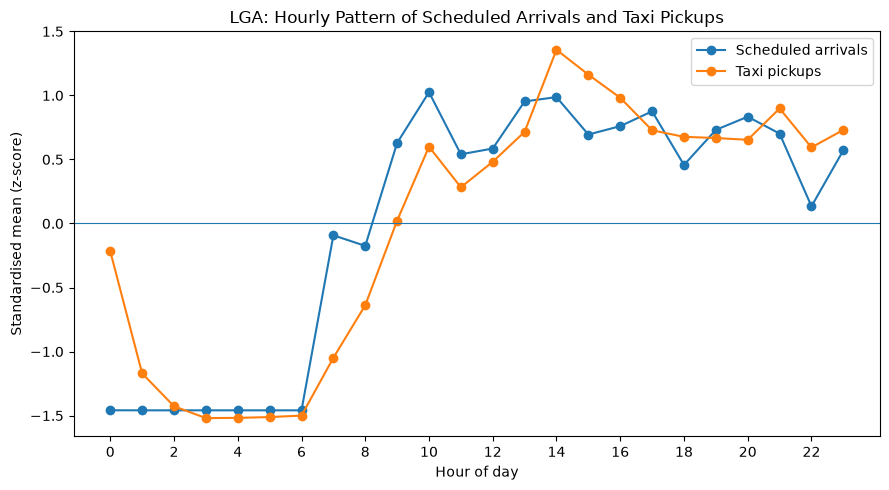

In [13]:
# Plot standardised hourly patterns for LGA
lga_profile = hourly_profile_pd[
    hourly_profile_pd["airport"] == "LGA"
]

plt.figure(figsize=(9, 5))

plt.plot(
    lga_profile["hour_of_day"],
    lga_profile["flight_index"],
    marker="o",
    label="Scheduled arrivals"
)

plt.plot(
    lga_profile["hour_of_day"],
    lga_profile["taxi_index"],
    marker="o",
    label="Taxi pickups"
)

plt.axhline(0, linewidth=0.8)

plt.xlabel("Hour of day")
plt.ylabel("Standardised mean (z-score)")
plt.title("LGA: Hourly Pattern of Scheduled Arrivals and Taxi Pickups")
plt.xticks(range(0, 24, 2))
plt.legend()
plt.tight_layout()

plt.show()

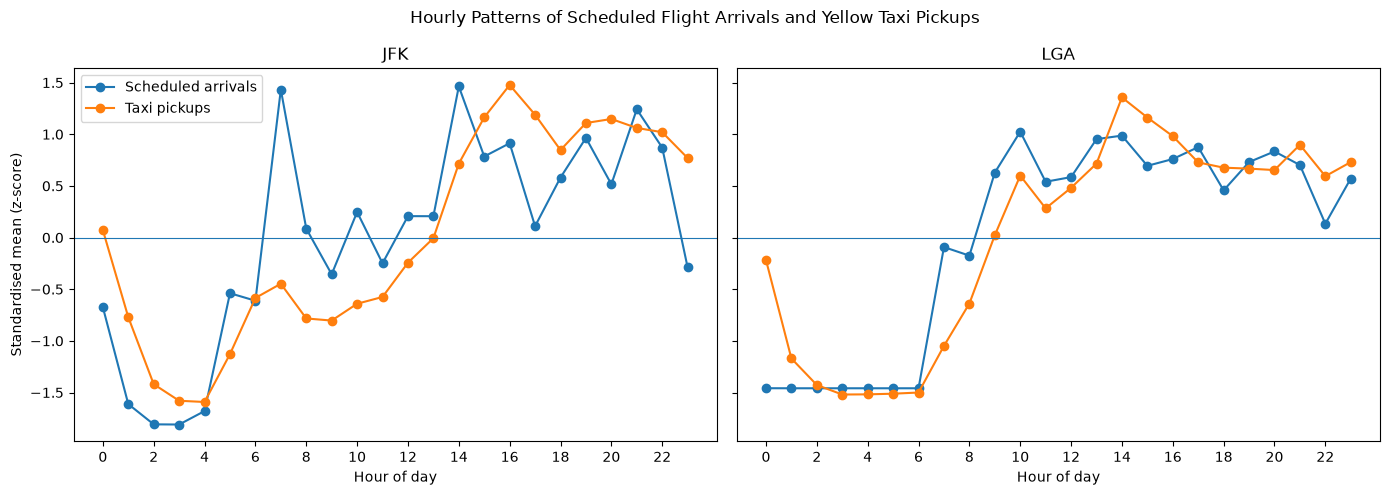

In [28]:
# Combined hourly pattern figure for report
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, airport, profile in [
    (axes[0], "JFK", jfk_profile),
    (axes[1], "LGA", lga_profile)
]:
    ax.plot(
        profile["hour_of_day"],
        profile["flight_index"],
        marker="o",
        label="Scheduled arrivals"
    )

    ax.plot(
        profile["hour_of_day"],
        profile["taxi_index"],
        marker="o",
        label="Taxi pickups"
    )

    ax.axhline(0, linewidth=0.8)
    ax.set_title(airport)
    ax.set_xlabel("Hour of day")
    ax.set_xticks(range(0, 24, 2))

axes[0].set_ylabel("Standardised mean (z-score)")
axes[0].legend()

fig.suptitle(
    "Hourly Patterns of Scheduled Flight Arrivals and Yellow Taxi Pickups"
)

plt.tight_layout()

plt.savefig(
    "../plots/hourly_arrivals_taxi_profiles.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 3. Lagged Relationship Analysis

The hourly profiles suggest that scheduled flight arrivals and taxi pickup demand may not peak simultaneously, particularly at JFK. To quantify this relationship, correlations are calculated between current taxi pickup demand and scheduled flight arrivals at several preceding hours.

This allows us to assess whether flight schedules provide useful advance information for anticipating subsequent taxi demand.

In [14]:
from pyspark.sql import Window

window_spec = (
    Window
    .partitionBy("airport")
    .orderBy("hour")
)

lagged_panel = airport_hour_panel

for lag in range(0, 5):
    if lag == 0:
        lagged_panel = lagged_panel.withColumn(
            "arrivals_lag_0",
            F.col("scheduled_arrivals")
        )
    else:
        lagged_panel = lagged_panel.withColumn(
            f"arrivals_lag_{lag}",
            F.lag("scheduled_arrivals", lag).over(window_spec)
        )

In [15]:
for airport in ["JFK", "LGA"]:
    print(f"\n{airport}")

    airport_df = lagged_panel.filter(
        F.col("airport") == airport
    )

    for lag in range(0, 5):
        corr_value = airport_df.stat.corr(
            "taxi_pickups",
            f"arrivals_lag_{lag}"
        )

        print(
            f"Lag {lag} hour(s): {corr_value:.4f}"
        )


JFK
Lag 0 hour(s): 0.6464
Lag 1 hour(s): 0.6807
Lag 2 hour(s): 0.6273
Lag 3 hour(s): 0.4902
Lag 4 hour(s): 0.3528

LGA
Lag 0 hour(s): 0.8036
Lag 1 hour(s): 0.8378
Lag 2 hour(s): 0.7774
Lag 3 hour(s): 0.6713
Lag 4 hour(s): 0.5168


In [16]:
# Calculate airport-specific hourly means
hourly_baseline = (
    airport_hour_panel
    .groupBy("airport", "hour_of_day")
    .agg(
        F.mean("scheduled_arrivals").alias("mean_arrivals_by_hour"),
        F.mean("taxi_pickups").alias("mean_taxi_by_hour")
    )
)

In [17]:
# Remove typical hour-of-day patterns from both variables
adjusted_panel = (
    airport_hour_panel
    .join(
        hourly_baseline,
        on=["airport", "hour_of_day"],
        how="left"
    )
    .withColumn(
        "arrivals_adjusted",
        F.col("scheduled_arrivals") - F.col("mean_arrivals_by_hour")
    )
    .withColumn(
        "taxi_adjusted",
        F.col("taxi_pickups") - F.col("mean_taxi_by_hour")
    )
)

In [18]:
adjusted_window = (
    Window
    .partitionBy("airport")
    .orderBy("hour")
)

adjusted_lagged = adjusted_panel

for lag in range(0, 5):
    if lag == 0:
        adjusted_lagged = adjusted_lagged.withColumn(
            "adjusted_arrivals_lag_0",
            F.col("arrivals_adjusted")
        )
    else:
        adjusted_lagged = adjusted_lagged.withColumn(
            f"adjusted_arrivals_lag_{lag}",
            F.lag("arrivals_adjusted", lag).over(adjusted_window)
        )

In [19]:
for airport in ["JFK", "LGA"]:
    print(f"\n{airport}")

    airport_df = adjusted_lagged.filter(
        F.col("airport") == airport
    )

    for lag in range(0, 5):
        corr_value = airport_df.stat.corr(
            "taxi_adjusted",
            f"adjusted_arrivals_lag_{lag}"
        )

        print(
            f"Adjusted lag {lag} hour(s): {corr_value:.4f}"
        )


JFK
Adjusted lag 0 hour(s): 0.1039
Adjusted lag 1 hour(s): 0.0831
Adjusted lag 2 hour(s): 0.0841
Adjusted lag 3 hour(s): 0.0511
Adjusted lag 4 hour(s): 0.0606

LGA
Adjusted lag 0 hour(s): 0.4585
Adjusted lag 1 hour(s): 0.4850
Adjusted lag 2 hour(s): 0.4692
Adjusted lag 3 hour(s): 0.4402
Adjusted lag 4 hour(s): 0.3821


In [20]:
# Automatically calculate raw and hour-of-day adjusted correlations
lag_result_rows = []

for airport in ["JFK", "LGA"]:
    raw_df = lagged_panel.filter(
        F.col("airport") == airport
    )

    adjusted_df = adjusted_lagged.filter(
        F.col("airport") == airport
    )

    for lag in range(0, 5):
        raw_corr = raw_df.stat.corr(
            "taxi_pickups",
            f"arrivals_lag_{lag}"
        )

        adjusted_corr = adjusted_df.stat.corr(
            "taxi_adjusted",
            f"adjusted_arrivals_lag_{lag}"
        )

        lag_result_rows.append({
            "airport": airport,
            "lag": lag,
            "raw_correlation": raw_corr,
            "adjusted_correlation": adjusted_corr
        })

lag_results = pd.DataFrame(lag_result_rows)

lag_results

,airport,lag,raw_correlation,adjusted_correlation
0,JFK,0,0.646418,0.103886
1,JFK,1,0.680736,0.083112
2,JFK,2,0.627324,0.084100
3,JFK,3,0.490196,0.051111
4,JFK,4,0.352768,0.060559
5,LGA,0,0.803585,0.458503
6,LGA,1,0.837759,0.484976
7,LGA,2,0.777398,0.469157
8,LGA,3,0.671274,0.440232
9,LGA,4,0.516847,0.382131


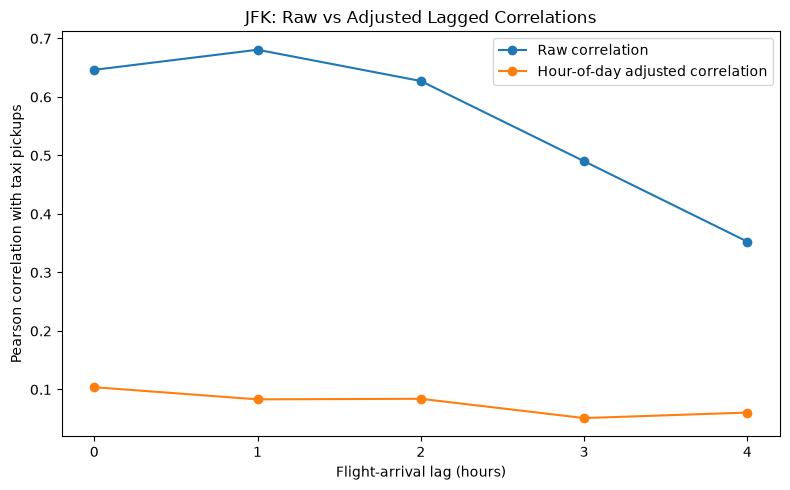

In [21]:
# Plot raw and adjusted lagged correlations for JFK
jfk_lag_results = lag_results[
    lag_results["airport"] == "JFK"
]

plt.figure(figsize=(8, 5))

plt.plot(
    jfk_lag_results["lag"],
    jfk_lag_results["raw_correlation"],
    marker="o",
    label="Raw correlation"
)

plt.plot(
    jfk_lag_results["lag"],
    jfk_lag_results["adjusted_correlation"],
    marker="o",
    label="Hour-of-day adjusted correlation"
)

plt.xlabel("Flight-arrival lag (hours)")
plt.ylabel("Pearson correlation with taxi pickups")
plt.title("JFK: Raw vs Adjusted Lagged Correlations")
plt.xticks(range(5))
plt.legend()
plt.tight_layout()

plt.show()

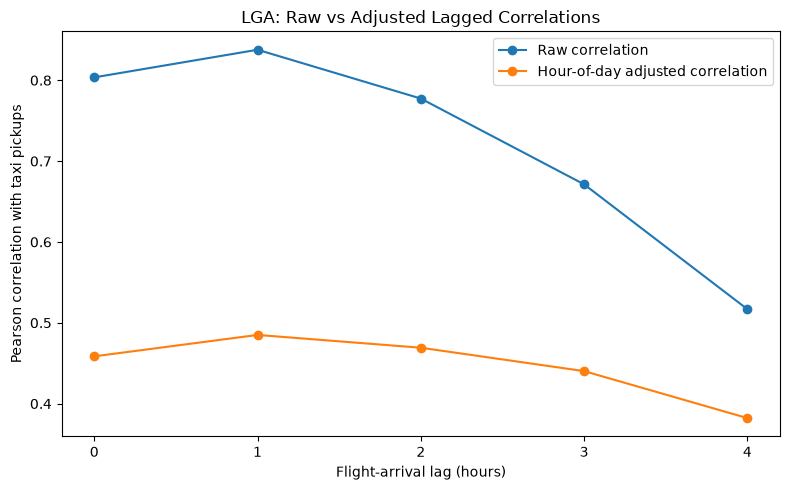

In [22]:
# Plot raw and adjusted lagged correlations for LGA
lga_lag_results = lag_results[
    lag_results["airport"] == "LGA"
]

plt.figure(figsize=(8, 5))

plt.plot(
    lga_lag_results["lag"],
    lga_lag_results["raw_correlation"],
    marker="o",
    label="Raw correlation"
)

plt.plot(
    lga_lag_results["lag"],
    lga_lag_results["adjusted_correlation"],
    marker="o",
    label="Hour-of-day adjusted correlation"
)

plt.xlabel("Flight-arrival lag (hours)")
plt.ylabel("Pearson correlation with taxi pickups")
plt.title("LGA: Raw vs Adjusted Lagged Correlations")
plt.xticks(range(5))
plt.legend()
plt.tight_layout()

plt.show()

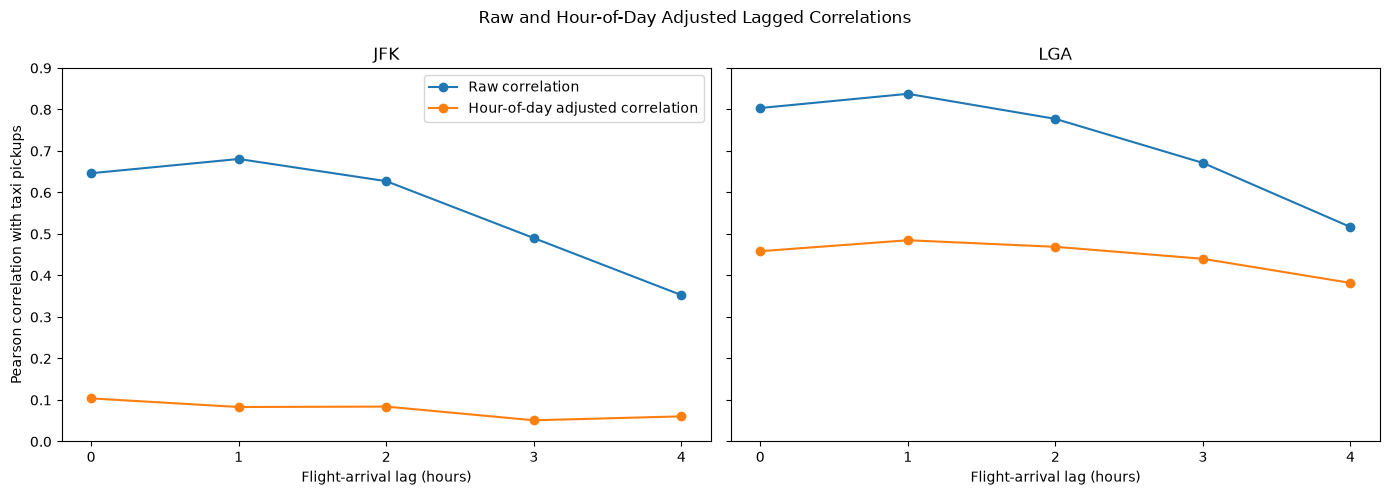

In [29]:
# Combined raw and adjusted lag-correlation figure for report
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, airport in zip(axes, ["JFK", "LGA"]):
    airport_results = lag_results[
        lag_results["airport"] == airport
    ]

    ax.plot(
        airport_results["lag"],
        airport_results["raw_correlation"],
        marker="o",
        label="Raw correlation"
    )

    ax.plot(
        airport_results["lag"],
        airport_results["adjusted_correlation"],
        marker="o",
        label="Hour-of-day adjusted correlation"
    )

    ax.set_title(airport)
    ax.set_xlabel("Flight-arrival lag (hours)")
    ax.set_xticks(range(5))
    ax.set_ylim(0, 0.9)

axes[0].set_ylabel(
    "Pearson correlation with taxi pickups"
)

axes[0].legend()

fig.suptitle(
    "Raw and Hour-of-Day Adjusted Lagged Correlations"
)

plt.tight_layout()

plt.savefig(
    "../plots/lagged_correlations_by_airport.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 4. Temporal Demand Patterns

Taxi pickup demand may vary systematically across both hour of day and day type. Before modelling, weekday and weekend demand profiles are compared to determine whether calendar effects provide useful information beyond scheduled flight arrivals.

This comparison also helps identify whether temporal demand patterns differ between JFK and LaGuardia.

In [23]:
# Classify observations as weekdays or weekends
airport_hour_panel = airport_hour_panel.withColumn(
    "day_type",
    F.when(
        F.col("day_of_week").isin([1, 7]),
        "Weekend"
    ).otherwise("Weekday")
)

airport_hour_panel.groupBy("day_type").count().show()

+--------+-----+
|day_type|count|
+--------+-----+
| Weekday| 6192|
| Weekend| 2496|
+--------+-----+



###  Weekday and Weekend Hourly Demand Profiles

Mean Yellow Taxi pickups are calculated for each hour of day separately for weekdays and weekends. Aggregation is performed in PySpark before the small summary table is converted to pandas for visualisation.

In [24]:
# Calculate mean hourly taxi demand by airport and day type
day_type_profile = (
    airport_hour_panel
    .groupBy(
        "airport",
        "day_type",
        "hour_of_day"
    )
    .agg(
        F.round(
            F.mean("taxi_pickups"),
            2
        ).alias("mean_taxi_pickups")
    )
    .orderBy(
        "airport",
        "day_type",
        "hour_of_day"
    )
)

print("Aggregated rows:", day_type_profile.count())

day_type_profile.show(20, truncate=False)

Aggregated rows: 96
+-------+--------+-----------+-----------------+
|airport|day_type|hour_of_day|mean_taxi_pickups|
+-------+--------+-----------+-----------------+
|JFK    |Weekday |0          |251.26           |
|JFK    |Weekday |1          |138.91           |
|JFK    |Weekday |2          |46.09            |
|JFK    |Weekday |3          |23.53            |
|JFK    |Weekday |4          |23.37            |
|JFK    |Weekday |5          |85.12            |
|JFK    |Weekday |6          |155.51           |
|JFK    |Weekday |7          |171.35           |
|JFK    |Weekday |8          |125.29           |
|JFK    |Weekday |9          |120.83           |
|JFK    |Weekday |10         |141.72           |
|JFK    |Weekday |11         |152.02           |
|JFK    |Weekday |12         |193.0            |
|JFK    |Weekday |13         |215.5            |
|JFK    |Weekday |14         |312.74           |
|JFK    |Weekday |15         |363.87           |
|JFK    |Weekday |16         |408.02           |


In [25]:
# Convert only the aggregated 96-row summary to pandas for plotting
day_type_pd = day_type_profile.toPandas()

day_type_pd.head()

,airport,day_type,hour_of_day,mean_taxi_pickups
0,JFK,Weekday,0,251.26
1,JFK,Weekday,1,138.91
2,JFK,Weekday,2,46.09
3,JFK,Weekday,3,23.53
4,JFK,Weekday,4,23.37


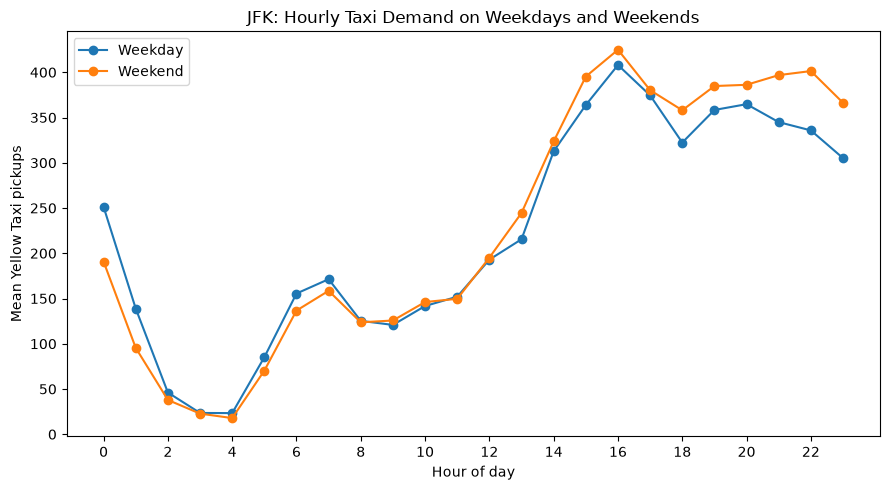

In [26]:
# Plot weekday and weekend hourly taxi-demand profiles for JFK
jfk_day_type = day_type_pd[
    day_type_pd["airport"] == "JFK"
]

plt.figure(figsize=(9, 5))

for day_type in ["Weekday", "Weekend"]:
    subset = jfk_day_type[
        jfk_day_type["day_type"] == day_type
    ]

    plt.plot(
        subset["hour_of_day"],
        subset["mean_taxi_pickups"],
        marker="o",
        label=day_type
    )

plt.xlabel("Hour of day")
plt.ylabel("Mean Yellow Taxi pickups")
plt.title("JFK: Hourly Taxi Demand on Weekdays and Weekends")
plt.xticks(range(0, 24, 2))
plt.legend()
plt.tight_layout()

plt.show()

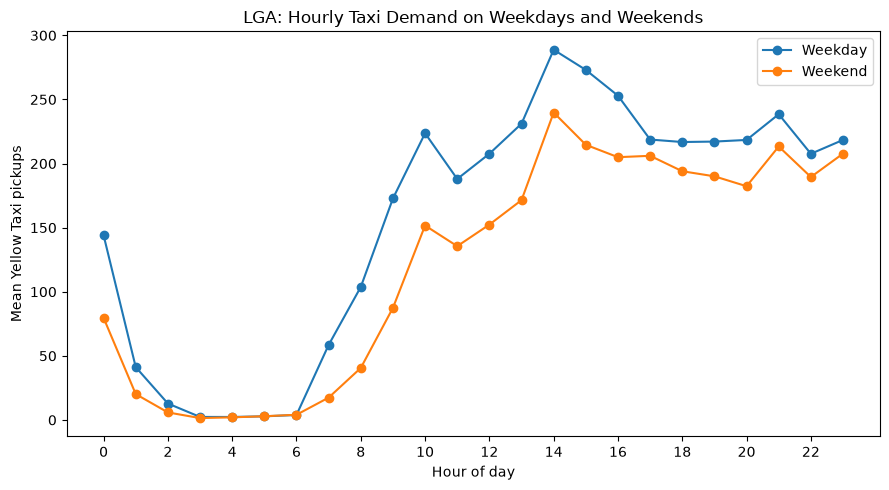

In [27]:
# Plot weekday and weekend hourly taxi-demand profiles for LGA
lga_day_type = day_type_pd[
    day_type_pd["airport"] == "LGA"
]

plt.figure(figsize=(9, 5))

for day_type in ["Weekday", "Weekend"]:
    subset = lga_day_type[
        lga_day_type["day_type"] == day_type
    ]

    plt.plot(
        subset["hour_of_day"],
        subset["mean_taxi_pickups"],
        marker="o",
        label=day_type
    )

plt.xlabel("Hour of day")
plt.ylabel("Mean Yellow Taxi pickups")
plt.title("LGA: Hourly Taxi Demand on Weekdays and Weekends")
plt.xticks(range(0, 24, 2))
plt.legend()
plt.tight_layout()

plt.show()

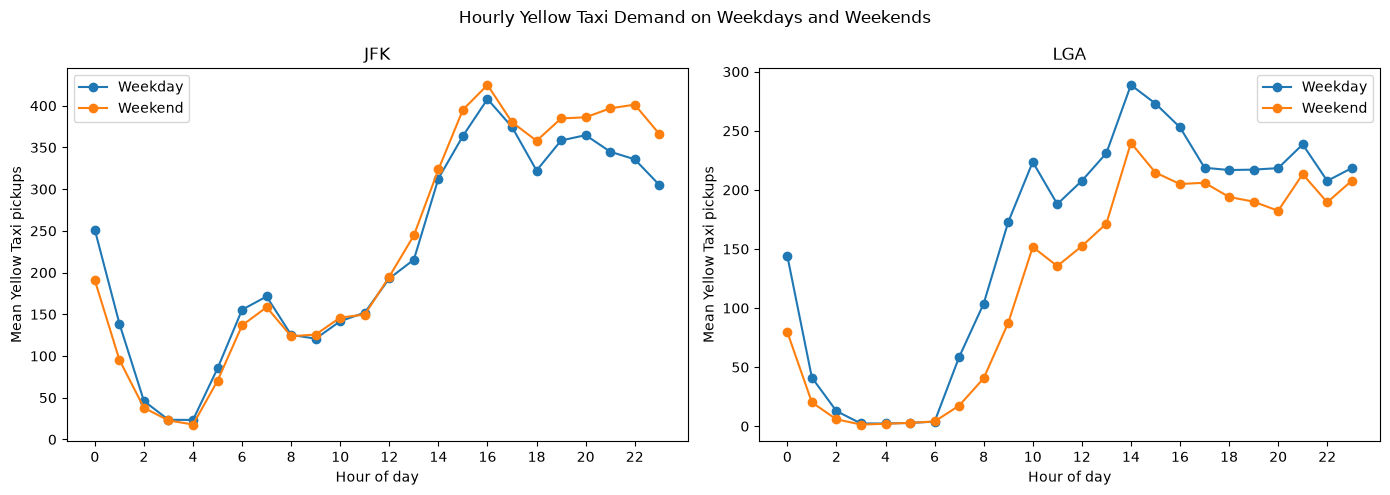

In [30]:
# Combined weekday/weekend taxi-demand profiles for report
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)

for ax, airport in zip(axes, ["JFK", "LGA"]):
    airport_data = day_type_pd[
        day_type_pd["airport"] == airport
    ]

    for day_type in ["Weekday", "Weekend"]:
        subset = airport_data[
            airport_data["day_type"] == day_type
        ]

        ax.plot(
            subset["hour_of_day"],
            subset["mean_taxi_pickups"],
            marker="o",
            label=day_type
        )

    ax.set_title(airport)
    ax.set_xlabel("Hour of day")
    ax.set_xticks(range(0, 24, 2))
    ax.legend()

axes[0].set_ylabel("Mean Yellow Taxi pickups")
axes[1].set_ylabel("Mean Yellow Taxi pickups")

fig.suptitle(
    "Hourly Yellow Taxi Demand on Weekdays and Weekends"
)

plt.tight_layout()

plt.savefig(
    "../plots/weekday_weekend_demand_by_airport.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Interpretation

The weekday–weekend comparison shows that taxi demand has substantial temporal structure beyond flight-arrival activity. At JFK, weekday and weekend profiles are broadly similar during much of the day, although weekend demand becomes noticeably higher during the evening. At LGA, weekday demand is consistently higher than weekend demand across much of the daytime and evening period.

These patterns indicate that both hour of day and day type should be considered when modelling airport taxi demand. They also suggest that the effect of day type may vary by airport and time of day.